In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers
import pandas as pd

In [4]:
base_dir = "./Dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")


In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ======================
# 1. Preprocessing and Augmentation Pipelines
# ======================
def build_preprocessing_pipeline():
    """Normalization and resizing"""
    return tf.keras.Sequential([
        layers.Resizing(*IMG_SIZE),
        layers.Rescaling(1./255)
    ])

def build_augmentation_pipeline():
    """Augmentation for training data only"""
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),  # Add vertical flips
        layers.RandomRotation(0.3),                   # Increase to ±30%
        layers.RandomZoom(0.3),                       # Increase to ±30%
        layers.RandomBrightness(0.2),                 # Add brightness jitter
        layers.RandomTranslation(0.1, 0.1)            # Add random shifts
    ])

In [8]:
# 2. Dataset Loading (Improved)
# ======================
def create_datasets():
    # Load raw datasets
    raw_train = image_dataset_from_directory(
        train_dir,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical'
    )
    
    raw_val = image_dataset_from_directory(
        train_dir,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical'
    )
    
    raw_test = image_dataset_from_directory(
        test_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=False
    )
    
    # Get class names from first dataset
    class_names = raw_train.class_names
    print("Class names:", class_names)
    
    # Build pipelines
    preprocessing = build_preprocessing_pipeline()
    augmentation = build_augmentation_pipeline()
    
    # Apply transformations
    train_ds = raw_train.map(lambda x, y: (preprocessing(x), y))
    train_ds = train_ds.map(lambda x, y: (augmentation(x, training=True), y))
    
    val_ds = raw_val.map(lambda x, y: (preprocessing(x), y))
    test_ds = raw_test.map(lambda x, y: (preprocessing(x), y))
    
    # Optimize pipeline
    return (
        train_ds.prefetch(tf.data.AUTOTUNE),
        val_ds.prefetch(tf.data.AUTOTUNE),
        test_ds.prefetch(tf.data.AUTOTUNE),
        class_names
    )

# Create datasets
train_dataset, val_dataset, test_dataset, class_names = create_datasets()


Found 34277 files belonging to 5 classes.
Using 27422 files for training.


2025-05-18 19:08:35.330942: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 34277 files belonging to 5 classes.
Using 6855 files for validation.
Found 8673 files belonging to 5 classes.
Class names: ['Bio-degradable', 'Electronic', 'Medical', 'Non-degradable', 'Recyclable']


2025-05-18 19:10:12.531116: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_5}}
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.034179].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0406097].
Clipping input data 


Training Set - Pixel Values:
Min: 0.0000, Max: 1.0552


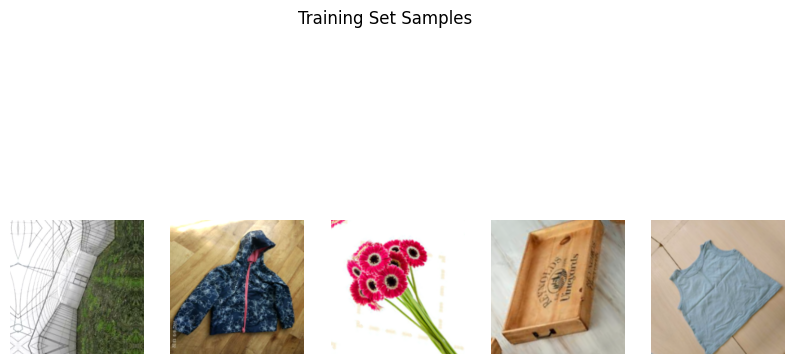

2025-05-18 19:10:13.970505: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-18 19:20:25.884362: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


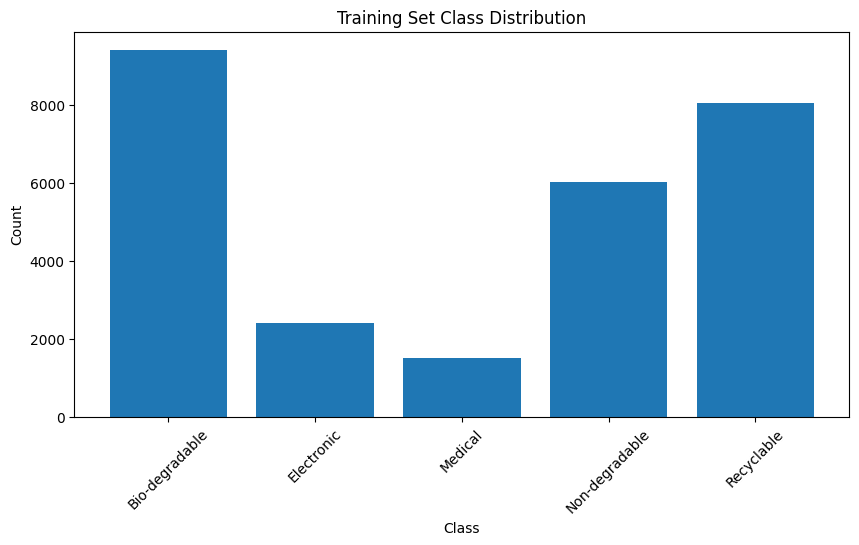


Validation Set - Pixel Values:
Min: 0.0000, Max: 1.0000


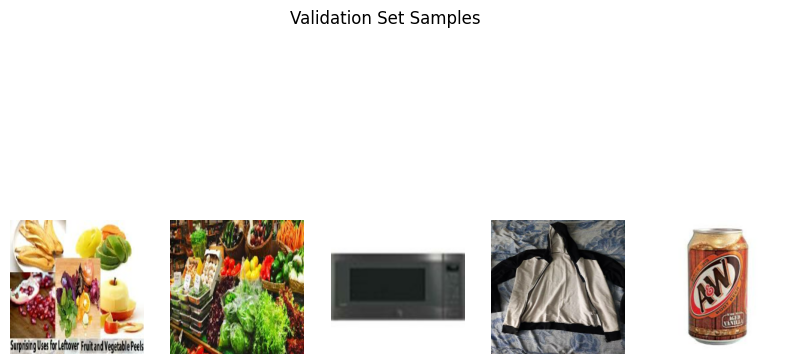

2025-05-18 19:20:31.994783: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


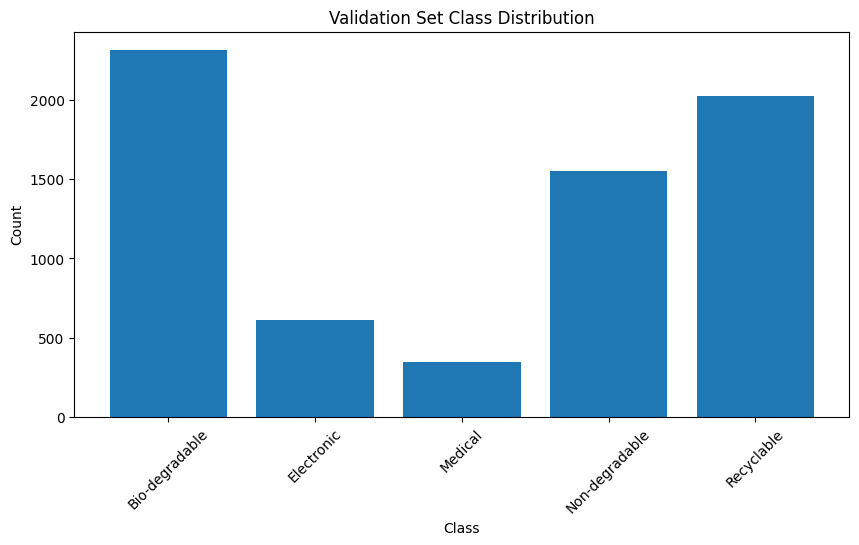

2025-05-18 19:20:32.387793: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Test Set - Pixel Values:
Min: 0.0000, Max: 1.0000


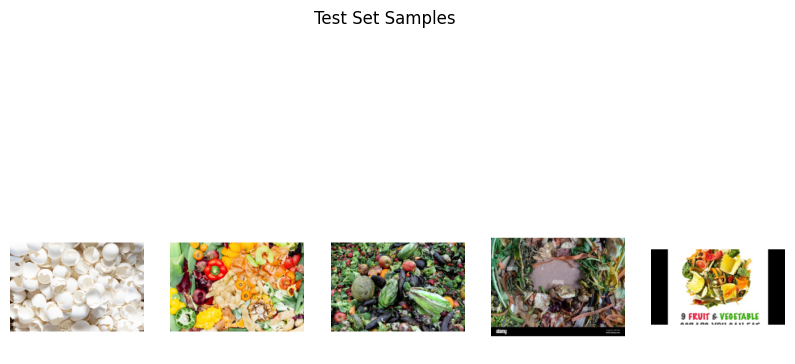

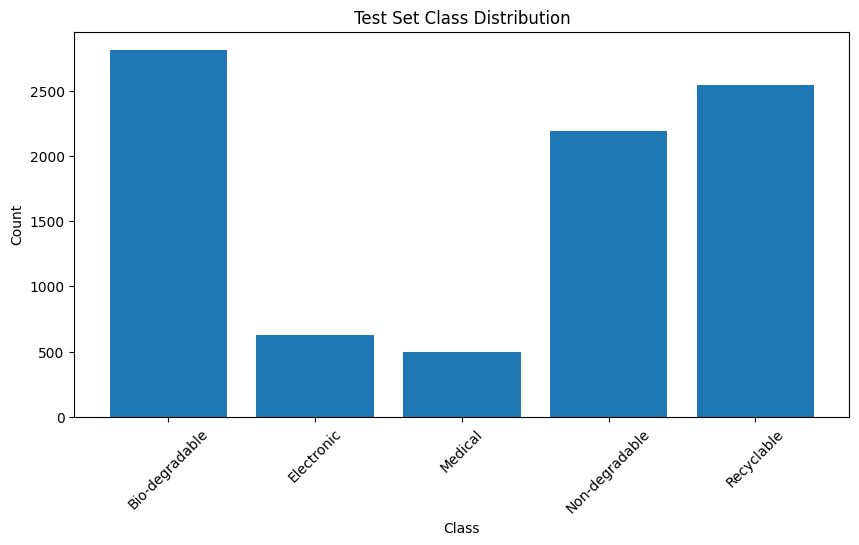

In [10]:
# 3. Visualization Functions (Unchanged)
# ======================
def plot_class_distribution(dataset, title):
    class_counts = {name: 0 for name in class_names}
    for _, labels in dataset:
        for batch_labels in labels:
            class_idx = tf.argmax(batch_labels).numpy()
            class_counts[class_names[class_idx]] += 1
    
    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
    return class_counts

def verify_and_visualize(dataset, title):
    # Pixel value check
    for images, _ in dataset.take(1):
        print(f"\n{title} - Pixel Values:")
        print(f"Min: {tf.reduce_min(images):.4f}, Max: {tf.reduce_max(images):.4f}")
        
        # Show samples
        plt.figure(figsize=(10, 5))
        for i in range(5):
            plt.subplot(1, 5, i+1)
            plt.imshow(images[i].numpy())
            plt.axis('off')
        plt.suptitle(f"{title} Samples", y=1.05)
        plt.show()
    
    # Class distribution
    plot_class_distribution(dataset, f"{title} Class Distribution")
    
if __name__ == "__main__":
    # Verify datasets
    verify_and_visualize(train_dataset, "Training Set")
    verify_and_visualize(val_dataset, "Validation Set")
    verify_and_visualize(test_dataset, "Test Set")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0502954].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0864155..1.009545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.001956135..1.037238].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0067544].
2025-05-18 19:21:04.155381: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


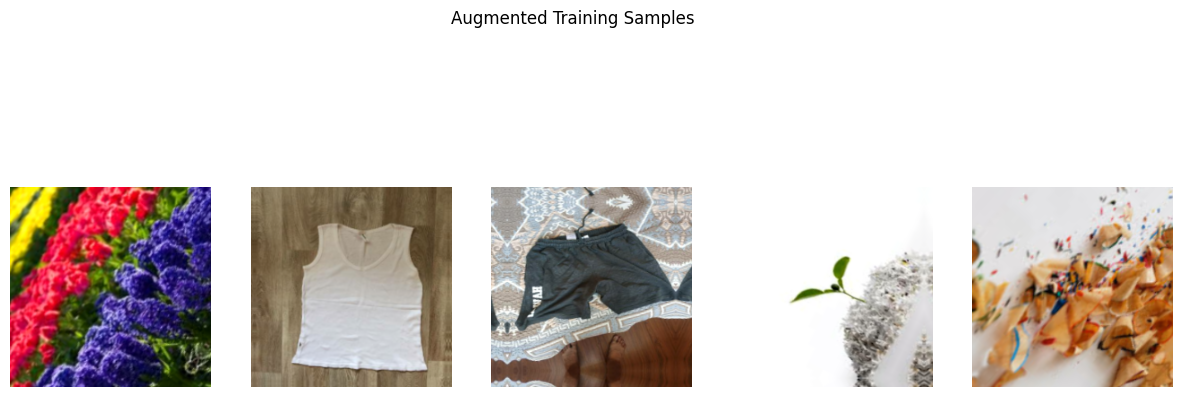

In [12]:
# Visualize augmented training samples
plt.figure(figsize=(15, 5))
for images, _ in train_dataset.take(1):
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].numpy())
        plt.axis('off')
plt.suptitle("Augmented Training Samples", y=1.05)
plt.show()